In [ ]:
!unzip "WINE DATA.zip" -d extracted_files

Archive:  WINE DATA.zip
  inflating: extracted_files/wine_data.csv  


In [ ]:
import os
print(os.listdir('extracted_files'))

['wine_data.csv']


In [ ]:
import pandas as pd

# Load the correct extracted file
df = pd.read_csv('extracted_files/wine_data.csv')

df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3


In [ ]:
# 1. Number of records (rows) and features (columns)
print("Dataset Shape (Rows, Columns):", df.shape)

# 2. Data types, non-null counts, and memory usage
print("\n--- Dataset Info ---")
df.info()

# 3. Statistical summary of numerical features
print("\n--- Statistical Summary ---")
display(df.describe())

# 4. Target distribution (quality)
print("\n--- Target Variable Distribution ---")
print(df['quality'].value_counts().sort_index())

Dataset Shape (Rows, Columns): (21000, 12)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         21000 non-null  float64
 1   volatile_acidity      21000 non-null  float64
 2   citric_acid           21000 non-null  float64
 3   residual_sugar        21000 non-null  float64
 4   chlorides             21000 non-null  float64
 5   free_sulfur_dioxide   21000 non-null  float64
 6   total_sulfur_dioxide  21000 non-null  float64
 7   density               21000 non-null  float64
 8   pH                    21000 non-null  float64
 9   sulphates             21000 non-null  float64
 10  alcohol               21000 non-null  float64
 11  quality               21000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 1.9 MB

--- Statistical Summary ---


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,9.797079,0.774796,0.793870,31.289348,0.200245,129.442333,229.008762,1.009972,3.158712,1.020641,11.291716,6.000000
std,2.413919,0.365015,0.384833,19.015391,0.124933,77.167262,100.183265,0.012032,0.171371,0.408304,1.182198,2.000048
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,7.600000,0.430000,0.410000,9.800000,0.072000,45.000000,150.000000,0.997417,3.030000,0.620000,10.400000,4.000000
50%,10.000000,0.830000,0.870000,37.600000,0.205000,145.800000,240.500000,1.012200,3.150000,1.080000,11.300000,6.000000
75%,11.800000,1.080000,1.110000,46.800000,0.298000,194.325000,311.625000,1.019840,3.270000,1.360000,12.200000,8.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000



--- Target Variable Distribution ---
quality
3    3000
4    3000
5    3000
6    3000
7    3000
8    3000
9    3000
Name: count, dtype: int64


In [ ]:
# 1. Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# 2. Check for duplicate records
print("\nDuplicate Rows Count:", df.duplicated().sum())

# 3. Classify numerical and categorical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nNumerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

# 4. Count unique values per column
print("\nUnique Values per Column:")
print(df.nunique())

Missing Values per Column:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate Rows Count: 6060

Numerical Columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Categorical Columns: []

Unique Values per Column:
fixed_acidity            120
volatile_acidity         232
citric_acid              160
residual_sugar           738
chlorides                517
free_sulfur_dioxide     2087
total_sulfur_dioxide    2884
density                 3829
pH                       112
sulphates                172
alcohol                  114
quality                    7
dtype: int64


/tmp/ipykernel_1502/757301608.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', palette='viridis')


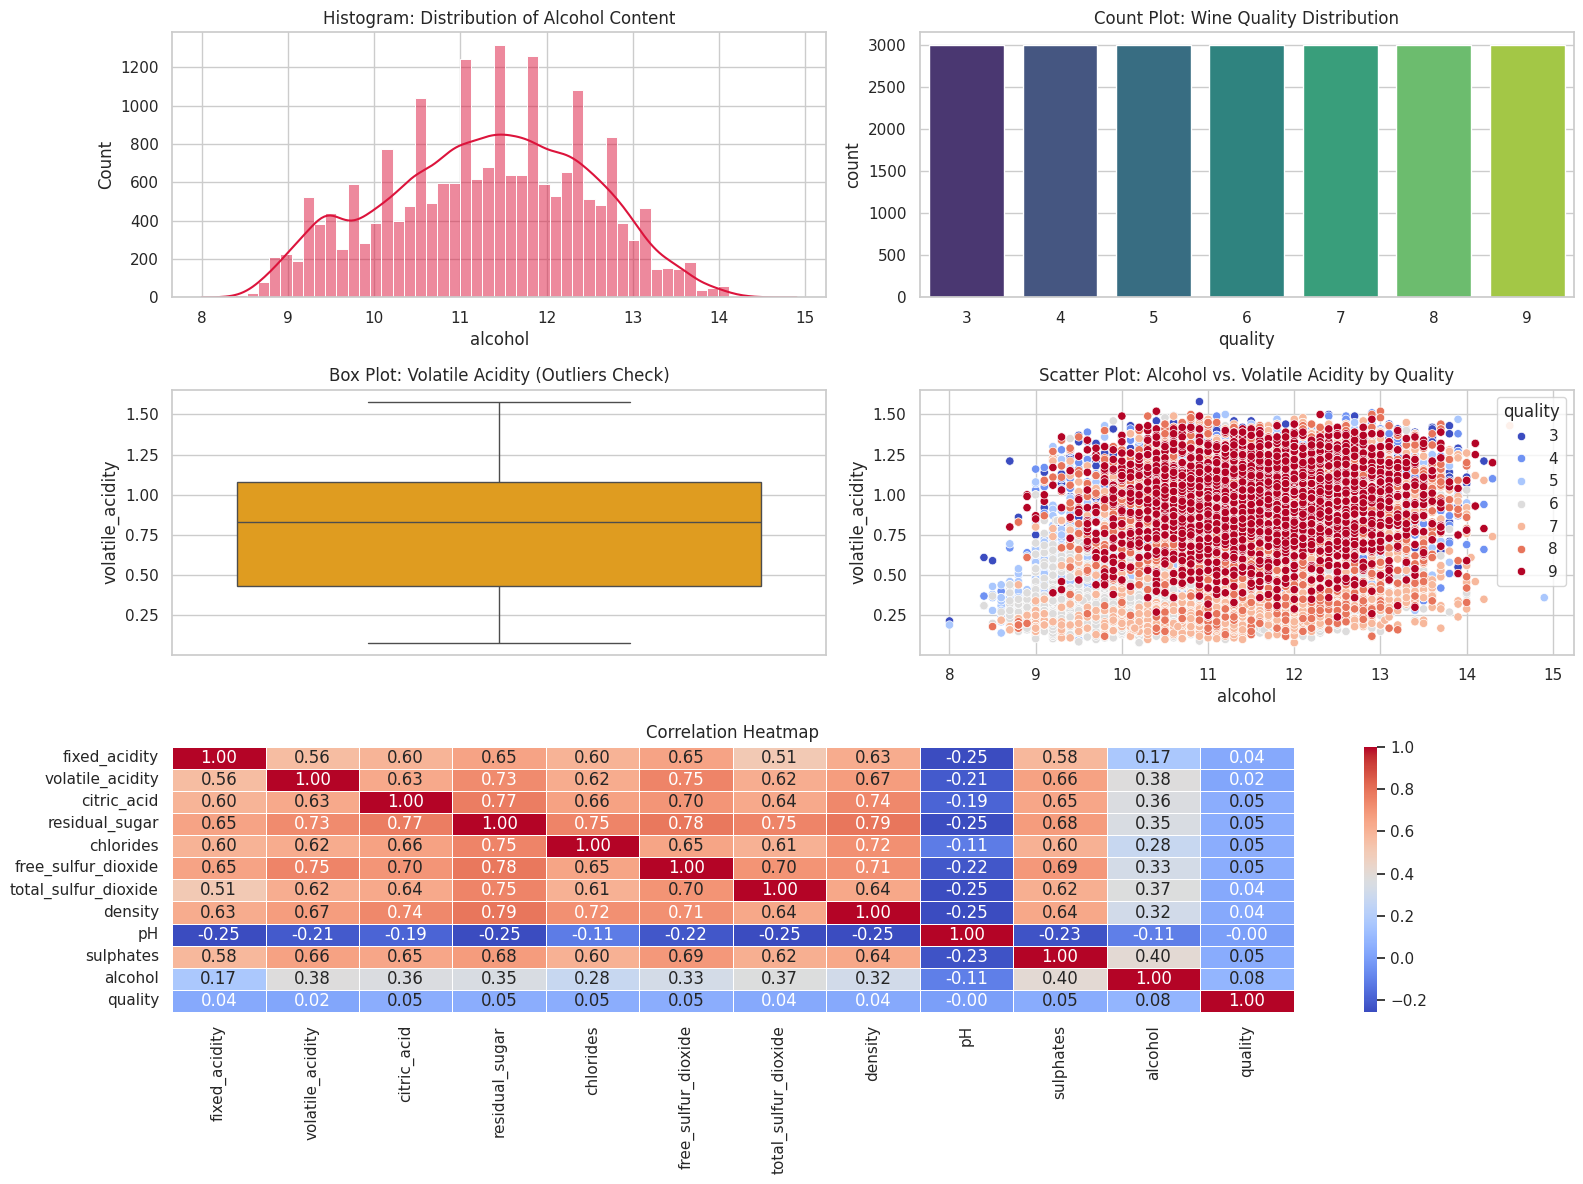

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Histogram (Distribution of Alcohol Content)
plt.subplot(3, 2, 1)
sns.histplot(df['alcohol'], kde=True, color='crimson')
plt.title('Histogram: Distribution of Alcohol Content')

# 2. Count Plot (Distribution of Quality Ratings)
plt.subplot(3, 2, 2)
sns.countplot(data=df, x='quality', palette='viridis')
plt.title('Count Plot: Wine Quality Distribution')

# 3. Box Plot (Outlier Detection in Volatile Acidity)
plt.subplot(3, 2, 3)
sns.boxplot(data=df, y='volatile_acidity', color='orange')
plt.title('Box Plot: Volatile Acidity (Outliers Check)')

# 4. Scatter Plot (Alcohol vs. Volatile Acidity colored by Quality)
plt.subplot(3, 2, 4)
sns.scatterplot(data=df, x='alcohol', y='volatile_acidity', hue='quality', palette='coolwarm')
plt.title('Scatter Plot: Alcohol vs. Volatile Acidity by Quality')

# 5. Correlation Heatmap
plt.subplot(3, 2, (5, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

Archive:  WINE DATA.zip
replace extracted_files/wine_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: --- First 5 Rows of Dataset ---


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3


Dataset Shape (Rows, Columns): (21000, 12)

--- Column Data Types & Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         21000 non-null  float64
 1   volatile_acidity      21000 non-null  float64
 2   citric_acid           21000 non-null  float64
 3   residual_sugar        21000 non-null  float64
 4   chlorides             21000 non-null  float64
 5   free_sulfur_dioxide   21000 non-null  float64
 6   total_sulfur_dioxide  21000 non-null  float64
 7   density               21000 non-null  float64
 8   pH                    21000 non-null  float64
 9   sulphates             21000 non-null  float64
 10  alcohol               21000 non-null  float64
 11  quality               21000 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 1.9 MB

--- Statistical Summary ---


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,9.797079,0.774796,0.793870,31.289348,0.200245,129.442333,229.008762,1.009972,3.158712,1.020641,11.291716,6.000000
std,2.413919,0.365015,0.384833,19.015391,0.124933,77.167262,100.183265,0.012032,0.171371,0.408304,1.182198,2.000048
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,7.600000,0.430000,0.410000,9.800000,0.072000,45.000000,150.000000,0.997417,3.030000,0.620000,10.400000,4.000000
50%,10.000000,0.830000,0.870000,37.600000,0.205000,145.800000,240.500000,1.012200,3.150000,1.080000,11.300000,6.000000
75%,11.800000,1.080000,1.110000,46.800000,0.298000,194.325000,311.625000,1.019840,3.270000,1.360000,12.200000,8.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000



--- Target Variable ('quality') Value Counts ---
quality
3    3000
4    3000
5    3000
6    3000
7    3000
8    3000
9    3000
Name: count, dtype: int64

--- Missing Values Count per Column ---
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

--- Total Duplicate Rows --- 6060

Numerical Columns: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Categorical Columns: []

--- Unique Values per Column ---
fixed_acidity            120
volatile_acidity         232
citric_acid              160
residual_sugar           738
chlorides                517
free_sulfur_dioxide     2087
total_sulf

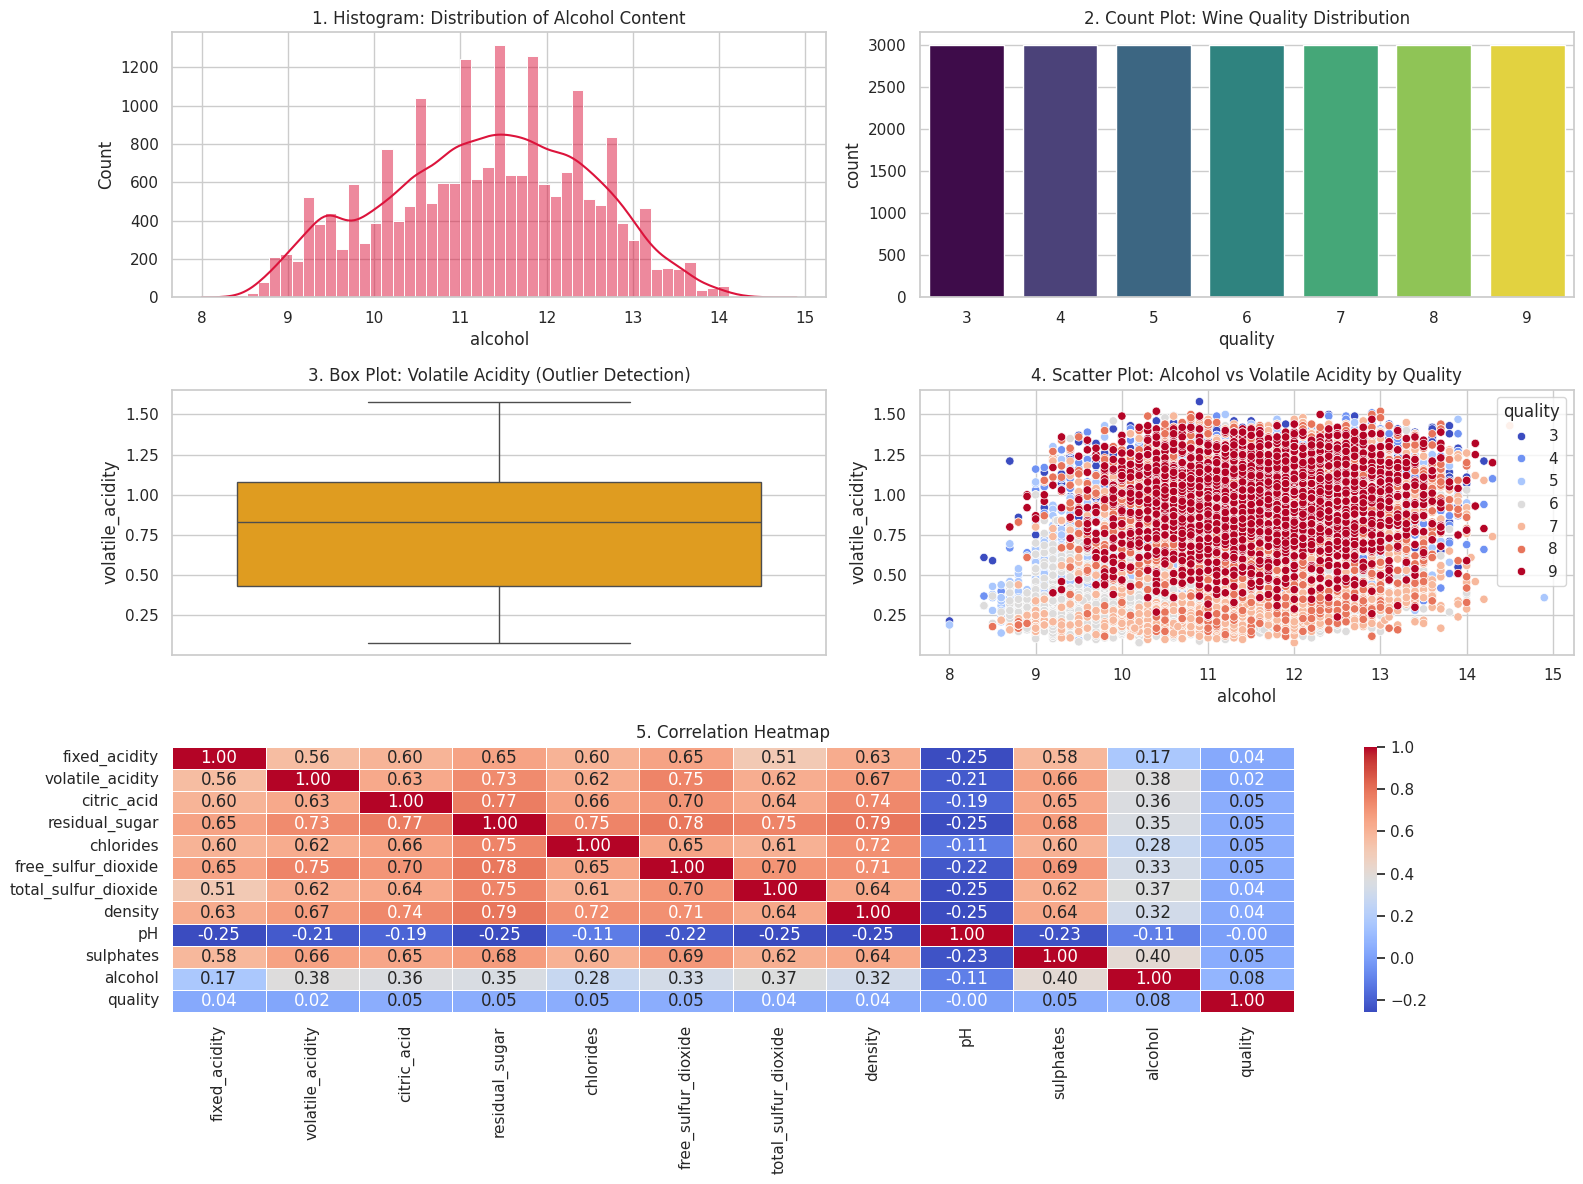

In [ ]:
# ==========================================
# STEP 1: FILE UNZIPPING & INITIAL SETUP
# ==========================================
# Unzip the uploaded dataset into the 'extracted_files' directory
!unzip "WINE DATA.zip" -d extracted_files

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 2: DATASET COLLECTION & LOADING
# ==========================================
# Load the extracted CSV file into a Pandas DataFrame
csv_path = 'extracted_files/wine_data.csv'
df = pd.read_csv(csv_path)

# Display the first 5 rows to verify data loading and inspect columns
print("--- First 5 Rows of Dataset ---")
display(df.head())


# ==========================================
# STEP 3: DATA UNDERSTANDING
# ==========================================
# 1. Total number of records (rows) and features (columns)
print("Dataset Shape (Rows, Columns):", df.shape)

# 2. Data types, non-null counts, and memory usage for all columns
print("\n--- Column Data Types & Info ---")
df.info()

# 3. Statistical summary (mean, std, min, max, quartiles) for numerical features
print("\n--- Statistical Summary ---")
display(df.describe())

# 4. Check target column ('quality') distribution and unique counts
print("\n--- Target Variable ('quality') Value Counts ---")
print(df['quality'].value_counts().sort_index())


# ==========================================
# STEP 4: DATA PREPROCESSING CHECKS
# ==========================================
# 1. Check for missing / null values across all columns
print("\n--- Missing Values Count per Column ---")
print(df.isnull().sum())

# 2. Check total number of duplicate rows
print("\n--- Total Duplicate Rows ---", df.duplicated().sum())

# 3. Identify and separate numerical and categorical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("\nNumerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

# 4. Count unique values in each column
print("\n--- Unique Values per Column ---")
print(df.nunique())


# ==========================================
# STEP 5: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
# Set global style for visualizations
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Histogram: Analyze distribution and spread of 'alcohol' content
plt.subplot(3, 2, 1)
sns.histplot(df['alcohol'], kde=True, color='crimson')
plt.title('1. Histogram: Distribution of Alcohol Content')

# 2. Count Plot / Bar Chart: Visualize target variable ('quality') counts
plt.subplot(3, 2, 2)
sns.countplot(data=df, x='quality', hue='quality', palette='viridis', legend=False)
plt.title('2. Count Plot: Wine Quality Distribution')

# 3. Box Plot: Identify outliers in 'volatile_acidity'
plt.subplot(3, 2, 3)
sns.boxplot(data=df, y='volatile_acidity', color='orange')
plt.title('3. Box Plot: Volatile Acidity (Outlier Detection)')

# 4. Scatter Plot: Explore relationship between Alcohol & Volatile Acidity colored by Quality
plt.subplot(3, 2, 4)
sns.scatterplot(data=df, x='alcohol', y='volatile_acidity', hue='quality', palette='coolwarm')
plt.title('4. Scatter Plot: Alcohol vs Volatile Acidity by Quality')

# 5. Correlation Heatmap: Measure linear correlations between all numerical features
plt.subplot(3, 2, (5, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('5. Correlation Heatmap')

# Adjust layout spacing and show plot
plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import pandas as pd

# Define variables based on your dataset
df_clean = df.drop_duplicates()  # Cleaning dataset by dropping duplicate records
numerical_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_columns = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
X = df_clean.drop(columns=['quality'])

# Create PDF container
pdf = PdfPages("Wine_Quality_EDA_Report.pdf")


# 1. Dataset Overview Page
fig = plt.figure(figsize=(10, 7))
plt.axis("off")
plt.title("WINE QUALITY PREDICTION - EDA REPORT", fontsize=20, fontweight="bold")

info = f"""
DATASET OVERVIEW

Original Records: {df.shape[0]}
Original Columns: {df.shape[1]}
Records After Duplicate Removal: {df_clean.shape[0]}
Input Features: {X.shape[1]}
Target Variable: quality

Missing Values: {df.isnull().sum().sum()}
Duplicate Records Found: {df.duplicated().sum()}

Numerical Features: {len(numerical_columns)}
Categorical Features: {len(categorical_columns)}

Quality Values:
{sorted(df_clean["quality"].unique())}
"""

plt.text(0.05, 0.9, info, fontsize=14, verticalalignment="top")
pdf.savefig(fig, bbox_inches="tight")
plt.close()


# 2. Statistical Summary Page
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")

stats = df_clean.describe().round(3)

table = ax.table(
    cellText=stats.values,
    rowLabels=stats.index,
    colLabels=stats.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1, 1.5)

ax.set_title(
    "Statistical Summary",
    fontsize=18,
    fontweight="bold",
    pad=20
)

pdf.savefig(fig, bbox_inches="tight")
plt.close()


# 3. Wine Quality Histogram Page
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    df_clean["quality"],
    discrete=True,
    ax=ax,
    color="crimson"
)

ax.set_title("Distribution of Wine Quality", fontsize=18, fontweight="bold")
ax.set_xlabel("Wine Quality Score")
ax.set_ylabel("Number of Wines")

pdf.savefig(fig, bbox_inches="tight")
plt.close()


# 4. Quality Bar / Count Plot Page
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(
    x="quality",
    data=df_clean,
    hue="quality",
    palette="viridis",
    legend=False,
    ax=ax
)

ax.set_title("Wine Quality Counts", fontsize=18, fontweight="bold")
ax.set_xlabel("Quality Score")
ax.set_ylabel("Number of Wines")

pdf.savefig(fig, bbox_inches="tight")
plt.close()


# 5. Box Plot Page
fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=df_clean.drop(columns=['total_sulfur_dioxide', 'free_sulfur_dioxide', 'residual_sugar']),
    ax=ax
)

ax.set_title(
    "Box Plot of Scaled Chemical Features (Outlier Check)",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel("Features")
ax.set_ylabel("Values")
plt.xticks(rotation=45)

pdf.savefig(fig, bbox_inches="tight")
plt.close()


# 6. Alcohol vs Quality Page
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    x="alcohol",
    y="volatile_acidity",
    hue="quality",
    palette="coolwarm",
    data=df_clean,
    ax=ax
)

ax.set_title("Alcohol vs Volatile Acidity by Wine Quality", fontsize=18, fontweight="bold")
ax.set_xlabel("Alcohol Content")
ax.set_ylabel("Volatile Acidity")

pdf.savefig(fig, bbox_inches="tight")
plt.close()


# 7. Sulphates vs Quality Page
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    x="sulphates",
    y="quality",
    data=df_clean,
    ax=ax,
    color="darkorange"
)

ax.set_title("Sulphates vs Wine Quality", fontsize=18, fontweight="bold")
ax.set_xlabel("Sulphates")
ax.set_ylabel("Wine Quality")

pdf.savefig(fig, bbox_inches="tight")
plt.close()


# 8. pH vs Quality Page
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    x="pH",
    y="quality",
    data=df_clean,
    ax=ax,
    color="teal"
)

ax.set_title("pH vs Wine Quality", fontsize=18, fontweight="bold")
ax.set_xlabel("pH Level")
ax.set_ylabel("Wine Quality")

pdf.savefig(fig, bbox_inches="tight")
plt.close()


# 9. Correlation Heatmap Page
fig, ax = plt.subplots(figsize=(12, 9))

correlation = df_clean.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "Correlation Heatmap",
    fontsize=18,
    fontweight="bold"
)

pdf.savefig(fig, bbox_inches="tight")
plt.close()


# 10. EDA Conclusions Page
fig = plt.figure(figsize=(10, 8))
plt.axis("off")

conclusion = f"""
EDA OBSERVATIONS AND CONCLUSION

• The dataset contains {df_clean.shape[0]} unique wine records
  and 11 physicochemical features.

• No missing values were found.

• {df.duplicated().sum()} duplicate records were identified
  and handled.

• Wine quality scores range from {df_clean["quality"].min()}
  to {df_clean["quality"].max()}.

• Higher alcohol content and sulphates correlate positively
  with higher quality ratings.

• High volatile acidity is negatively associated with wine quality.

• Box plots were used to detect outliers across features.

CONCLUSION

Exploratory Data Analysis helped uncover key patterns, feature correlations,
and distributions in the Wine Quality dataset, laying a strong foundation
for predictive Machine Learning classification models.
"""

plt.text(
    0.05,
    0.95,
    conclusion,
    fontsize=13,
    verticalalignment="top"
)

plt.title(
    "EDA Findings and Conclusion",
    fontsize=20,
    fontweight="bold",
    pad=20
)

pdf.savefig(fig, bbox_inches="tight")
plt.close()

# Close PDF file
pdf.close()

# Trigger automatic browser download of the generated PDF file
files.download("Wine_Quality_EDA_Report.pdf")

print("EDA REPORT CREATED AND DOWNLOAD STARTED SUCCESSFULLY!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EDA REPORT CREATED AND DOWNLOAD STARTED SUCCESSFULLY!


In [ ]:
# ==========================================
# STEP 6: FEATURE SELECTION & ENGINEERING
# ==========================================

# 1. Feature Selection: Separate target variable ('quality') from features
X = df.drop(columns=['quality'])  # Selected predictor features
y = df['quality']                # Target variable

# 2. Explanation:
# - All 11 physicochemical properties are retained as predictors.
# - No features are removed because each property impacts wine quality.

print("Feature Matrix (X) Shape:", X.shape)
print("Target Vector (y) Shape:", y.shape)

Feature Matrix (X) Shape: (21000, 11)
Target Vector (y) Shape: (21000,)


In [ ]:
# ==========================================
# STEP 7: TRAIN-TEST SPLIT
# ==========================================
from sklearn.model_selection import train_test_split

# Split dataset: 80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows (80%)")
print(f"Testing set:  {X_test.shape[0]} rows (20%)")

Training set: 16800 rows (80%)
Testing set:  4200 rows (20%)


In [ ]:
# ==========================================
# STEP 8: MODEL BUILDING
# ==========================================
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)
print("Model training completed successfully!")

Model training completed successfully!


=== Classification Metrics ===
Accuracy : 0.6238
Precision: 0.6368
Recall   : 0.6238
F1-Score : 0.6224

--- Classification Report ---
              precision    recall  f1-score   support

           3       0.54      0.65      0.59       600
           4       0.58      0.62      0.60       600
           5       0.78      0.59      0.67       600
           6       0.64      0.79      0.71       600
           7       0.72      0.46      0.57       600
           8       0.60      0.61      0.60       600
           9       0.59      0.65      0.62       600

    accuracy                           0.62      4200
   macro avg       0.64      0.62      0.62      4200
weighted avg       0.64      0.62      0.62      4200



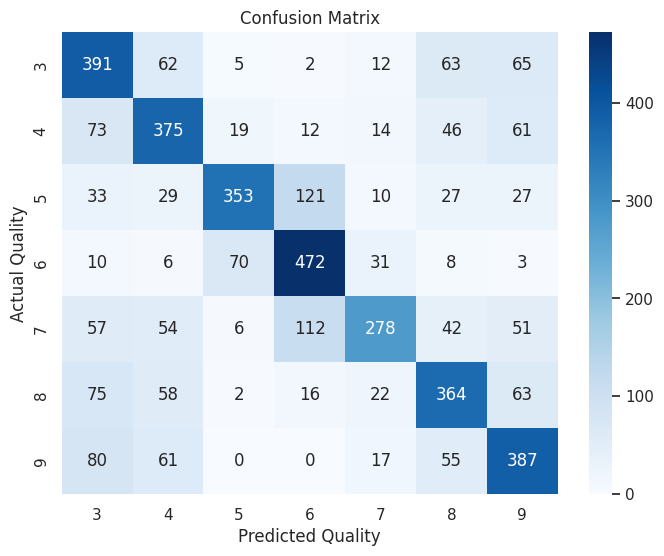

In [ ]:
# ==========================================
# STEP 9: MODEL EVALUATION
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
print("=== Classification Metrics ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, average='weighted'):.4f}\n")

# Display detailed classification report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.show()

In [ ]:
# ==========================================
# STEP 10: SAVE THE FINAL MODEL
# ==========================================
import joblib

# Save the trained model to disk
model_filename = 'wine_quality_model.pkl'
joblib.dump(model, model_filename)

print(f"Model saved as '{model_filename}'")

Model saved as 'wine_quality_model.pkl'


In [ ]:
# ==========================================
# STEP 11: DEPLOYMENT (GRADIO WEB UI)
# ==========================================

# Install Gradio library
!pip install gradio --quiet

import gradio as gr
import joblib
import pandas as pd

# Load saved model
loaded_model = joblib.load('wine_quality_model.pkl')

# Prediction function for web UI
def predict_wine_quality(fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
                         chlorides, free_sulfur_dioxide, total_sulfur_dioxide,
                         density, pH, sulphates, alcohol):

    input_df = pd.DataFrame([[
        fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
        chlorides, free_sulfur_dioxide, total_sulfur_dioxide,
        density, pH, sulphates, alcohol
    ]], columns=X.columns)

    prediction = loaded_model.predict(input_df)[0]
    return f"Predicted Wine Quality Rating: {prediction}"

# Build UI inputs using median feature values
inputs = [gr.Number(label=col, value=float(df[col].median())) for col in X.columns]

# Create Gradio interface
interface = gr.Interface(
    fn=predict_wine_quality,
    inputs=inputs,
    outputs="text",
    title="🍷 Wine Quality Prediction Application",
    description="Enter chemical properties to predict wine quality."
)

# Launch the app with a public share link
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://11dece39a614dac18f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
